In [1]:
import matplotlib.pyplot as plt

SA_RC = {
    # --- Figure ---
    'figure.figsize': (6, 4),
    'figure.dpi': 150,
    'figure.facecolor': 'white',
    'figure.autolayout': True,

    # --- Axes ---
    'axes.facecolor': 'white',
    'axes.edgecolor': '#444444',
    'axes.linewidth': 0.8,
    'axes.spines.top': True,  # both spines visible (commented-out removal kept)
    'axes.spines.right': True,
    'axes.labelsize': 12,
    'axes.labelcolor': 'black',
    'axes.titlelocation': 'center',

    # --- Grid ---
    'axes.grid': False,  # no grid in source plot

    # --- Ticks ---
    'xtick.labelsize': 12,
    'xtick.color': 'black',
    'xtick.direction': 'out',
    'ytick.labelsize': 10,
    'ytick.color': 'black',
    'ytick.direction': 'out',

    # --- Font ---
    'font.family': 'sans-serif',
    'font.serif': ['computer modern roman'],
    'font.sans-serif': ['Helvetica Neue LT Pro'],
    'font.size': 10,
    'text.color': 'black',
    'font.weight': '300', 'axes.labelweight': '500',

    # --- Patches (bars, legend swatches) ---
    'patch.edgecolor': 'black',
    'patch.linewidth': 0.7,
    'patch.force_edgecolor': True,

    # --- Legend ---
    'legend.fontsize': 8,
    'legend.title_fontsize': 9,
    'legend.framealpha': 0.0,  # transparent legend box
    'legend.edgecolor': '#444444',

    # --- Lines ---
    'lines.linewidth': 0.7,

    # --- Saving ---
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'savefig.facecolor': 'white',
}
plt.rcParams.update(SA_RC)
dir_paper_figure = r"D:\pykan\github\workflows\Hyein\figures_for_paper"

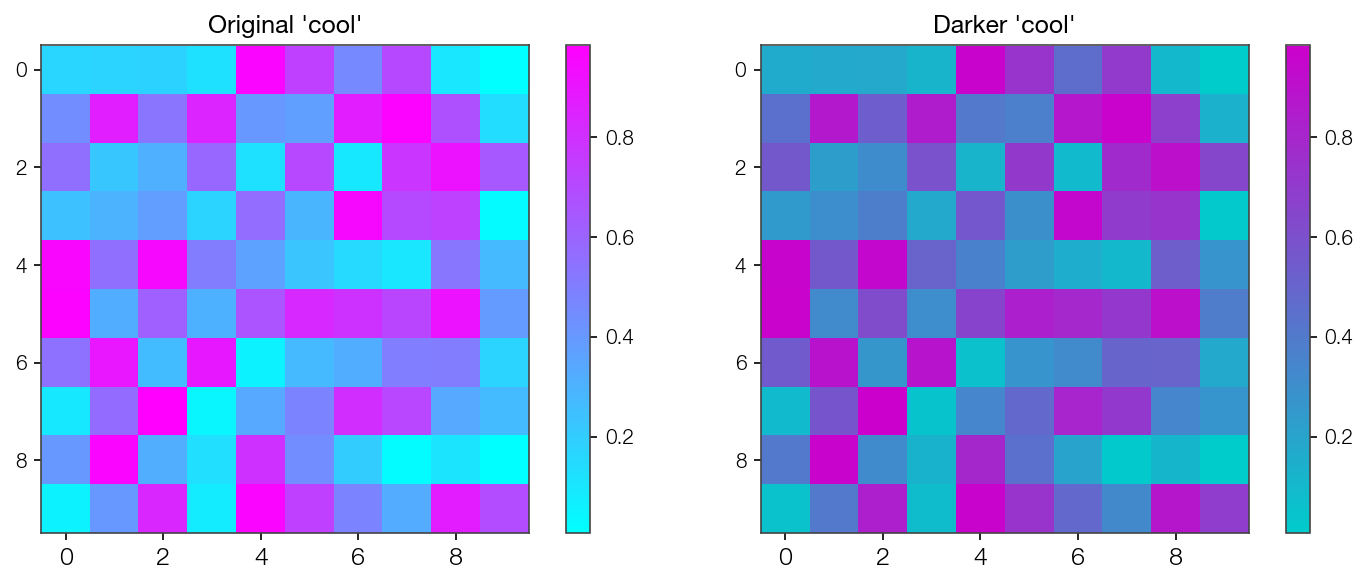

In [2]:
import matplotlib.colors as mcolors
import numpy as np

# 1. Retrieve the original colormap
orig_cmap = plt.get_cmap('cool')

# 2. Extract a continuous array of 256 colors from the map
# This returns an array of shape (256, 4) containing RGBA values
colors = orig_cmap(np.linspace(0, 1, 256))

# 3. Define the darkening factor (0.0 is pure black, 1.0 is original)
# 0.6 retains 60% of the original brightness
darken_factor = 0.8

# 4. Apply the factor to the RGB channels (indices 0, 1, 2)
# We leave the Alpha channel (index 3) untouched to preserve opacity
dark_colors = colors.copy()
dark_colors[:, :3] = dark_colors[:, :3] * darken_factor

# 5. Register the modified colors as a new colormap
darker_cmap = mcolors.LinearSegmentedColormap.from_list('cool_darker', dark_colors)

# --- Testing the Output ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
data = np.random.rand(10, 10)

# Original
im1 = ax1.imshow(data, cmap='cool')
ax1.set_title("Original 'cool'")
plt.colorbar(im1, ax=ax1)

# Darkened
im2 = ax2.imshow(data, cmap=darker_cmap)
ax2.set_title("Darker 'cool'")
plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.show()

## Analytic Function

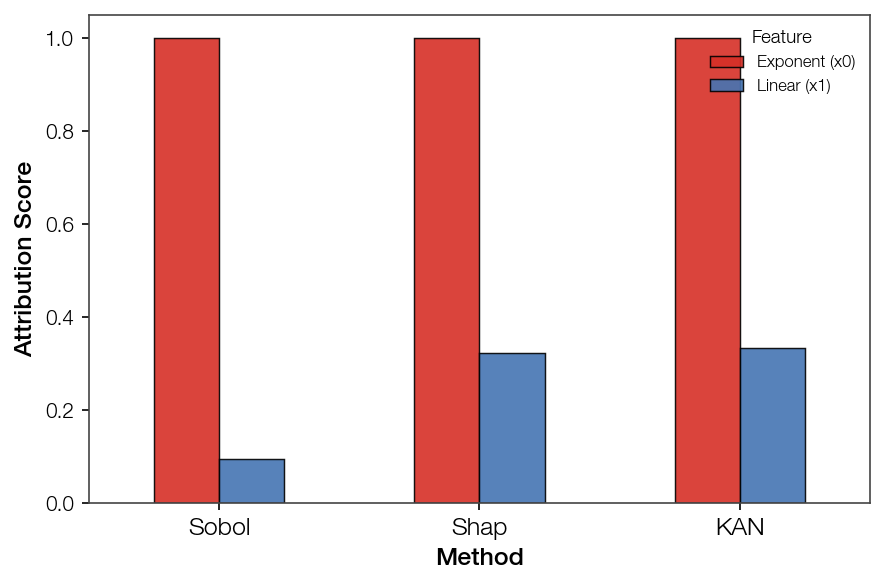

In [3]:
import pandas as pd
import os
import numpy as np

fun_analytic = 'exponential'

dir_analytic = r"D:\pykan\github\workflows\Hyein\analytical_results"
file_sobol = os.path.join(dir_analytic, fun_analytic, "sobol_indices_global.csv")
file_shap = os.path.join(dir_analytic, fun_analytic, "shap_mean_abs_global.csv")
file_kan = os.path.join(dir_analytic, fun_analytic, "kan_models", f"{fun_analytic}_global_attribution_scores.csv")

df_sobol = pd.read_csv(file_sobol)
feat_names = df_sobol['Feature'].tolist()
s_sobol = df_sobol['First_Order (S1)'].tolist()

df_shap = pd.read_csv(file_shap)
s_shap = df_shap['Mean_Abs_SHAP'].tolist()

df_KAN = pd.read_csv(file_kan)
s_kan = df_KAN['Global_Attribution_Score'].tolist()

s_ALL = {
    'Feature': feat_names,
    'Sobol': s_sobol,
    'Shap': s_shap,
    'KAN': s_kan
}
df_all = pd.DataFrame(s_ALL)

numeric_cols = ['Sobol', 'Shap', 'KAN']
df_all[numeric_cols] = df_all[numeric_cols] / df_all[numeric_cols].max()
# 2. Reshape the data for plotting
# Set 'Feature' as the index and select the method columns
df_methods = df_all.set_index('Feature')[numeric_cols]

# Transpose the DataFrame so Methods become the rows (x-axis)
# and Features become the columns (individual bars per group)
df_transposed = df_methods.T

# 3. Create the plot using pandas built-in wrapper
# This automatically handles dynamic counts of features
num_feat = len(feat_names)
cmap = plt.get_cmap('RdYlBu')
custom_colors = [cmap(x) for x in np.linspace(0.1, 0.9, num_feat)]
ax = df_transposed.plot(kind='bar', rot=0, color=custom_colors, alpha=0.9)

# 4. Customize axes and labels
ax.set_xlabel('Method')
ax.set_ylabel('Attribution Score')
ax.legend(title='Feature')

# Adjust layout and display
plt.savefig(os.path.join(dir_analytic, fun_analytic, "VS_conventional.png"))
plt.savefig(os.path.join(dir_analytic, fun_analytic, "VS_conventional.svg"), format='svg')
plt.savefig(os.path.join(dir_paper_figure, f"VS_conventional_{fun_analytic}.png"))
plt.savefig(os.path.join(dir_paper_figure, f"VS_conventional_{fun_analytic}.svg"), format='svg')
plt.show()

## Pre-defined Dataset

In [ ]:
import pandas as pd
import os
import numpy as np

name_data = 'CO2HPx10'

root_dir = r"D:\pykan\github\workflows\Hyein"
file_sobol = os.path.join(root_dir, "material_nn_models", name_data, f"{name_data}_sobol_indices.csv")
file_shap = os.path.join(root_dir, "material_nn_models", name_data, f"{name_data}_shap_importance.csv")
file_kan = os.path.join(root_dir, "material_kan_models", name_data, f"{name_data}_global_attribution_scores.csv")

files = [file_sobol, file_shap, file_kan]
columns = ['First_Order (S1)', 'Mean_Abs_SHAP', 'Global_Attribution_Score']
methods = ['Sobol', 'Shap', 'KAN']

dfs = [pd.read_csv(f) for f in files]
dfs = [d.set_index('Feature') for d in dfs]
s_ALL = [d[c] for d, c in zip(dfs, columns)]
df_methods = pd.concat(s_ALL, axis=1)
df_methods.columns = methods
df_methods.sort_values('KAN', inplace=True, ascending=False)
df_methods[methods] = df_methods[methods] / df_methods[methods].max()

df_methods.index = df_methods.index.str.replace(r'\s*\(.*?\)', '', regex=True)

# Transpose the DataFrame so Methods become the rows (x-axis)
# and Features become the columns (individual bars per group)
df_transposed = df_methods.T

# 3. Create the plot using pandas built-in wrapper
# This automatically handles dynamic counts of features
num_feat = len(df_transposed.columns)
cmap = plt.get_cmap('RdYlBu')
custom_colors = [cmap(x) for x in np.linspace(0.1, 0.9, num_feat)]
ax = df_transposed.plot(kind='bar', rot=0, color=custom_colors, alpha=0.9)

# 4. Customize axes and labels
ax.set_xlabel('Method')
ax.set_ylabel('Attribution Score')
if "CO2RR" in name_data:
    # ax.legend(title='Feature', loc='upper center', ncols=4)
    # y_min, y_max = ax.get_ylim()
    # ax.set_ylim([y_min, y_max*1.2])

    ax.legend(title='Feature', loc='upper right')
    x_min, x_max = ax.get_xlim()
    ax.set_xlim([x_min, x_max*1.15])

else:
    ax.legend(title='Feature')

# Adjust layout and display
plt.savefig(os.path.join(root_dir, "material_kan_models", name_data, f"{name_data}_VS_conventional.png"))
plt.savefig(os.path.join(root_dir, "material_kan_models", name_data, f"{name_data}_VS_conventional.svg"), format='svg')
plt.savefig(os.path.join(dir_paper_figure, f"VS_conventionals_{name_data}.png"))
plt.savefig(os.path.join(dir_paper_figure, f"VS_conventionals_{name_data}.svg"), format='svg')
plt.show()

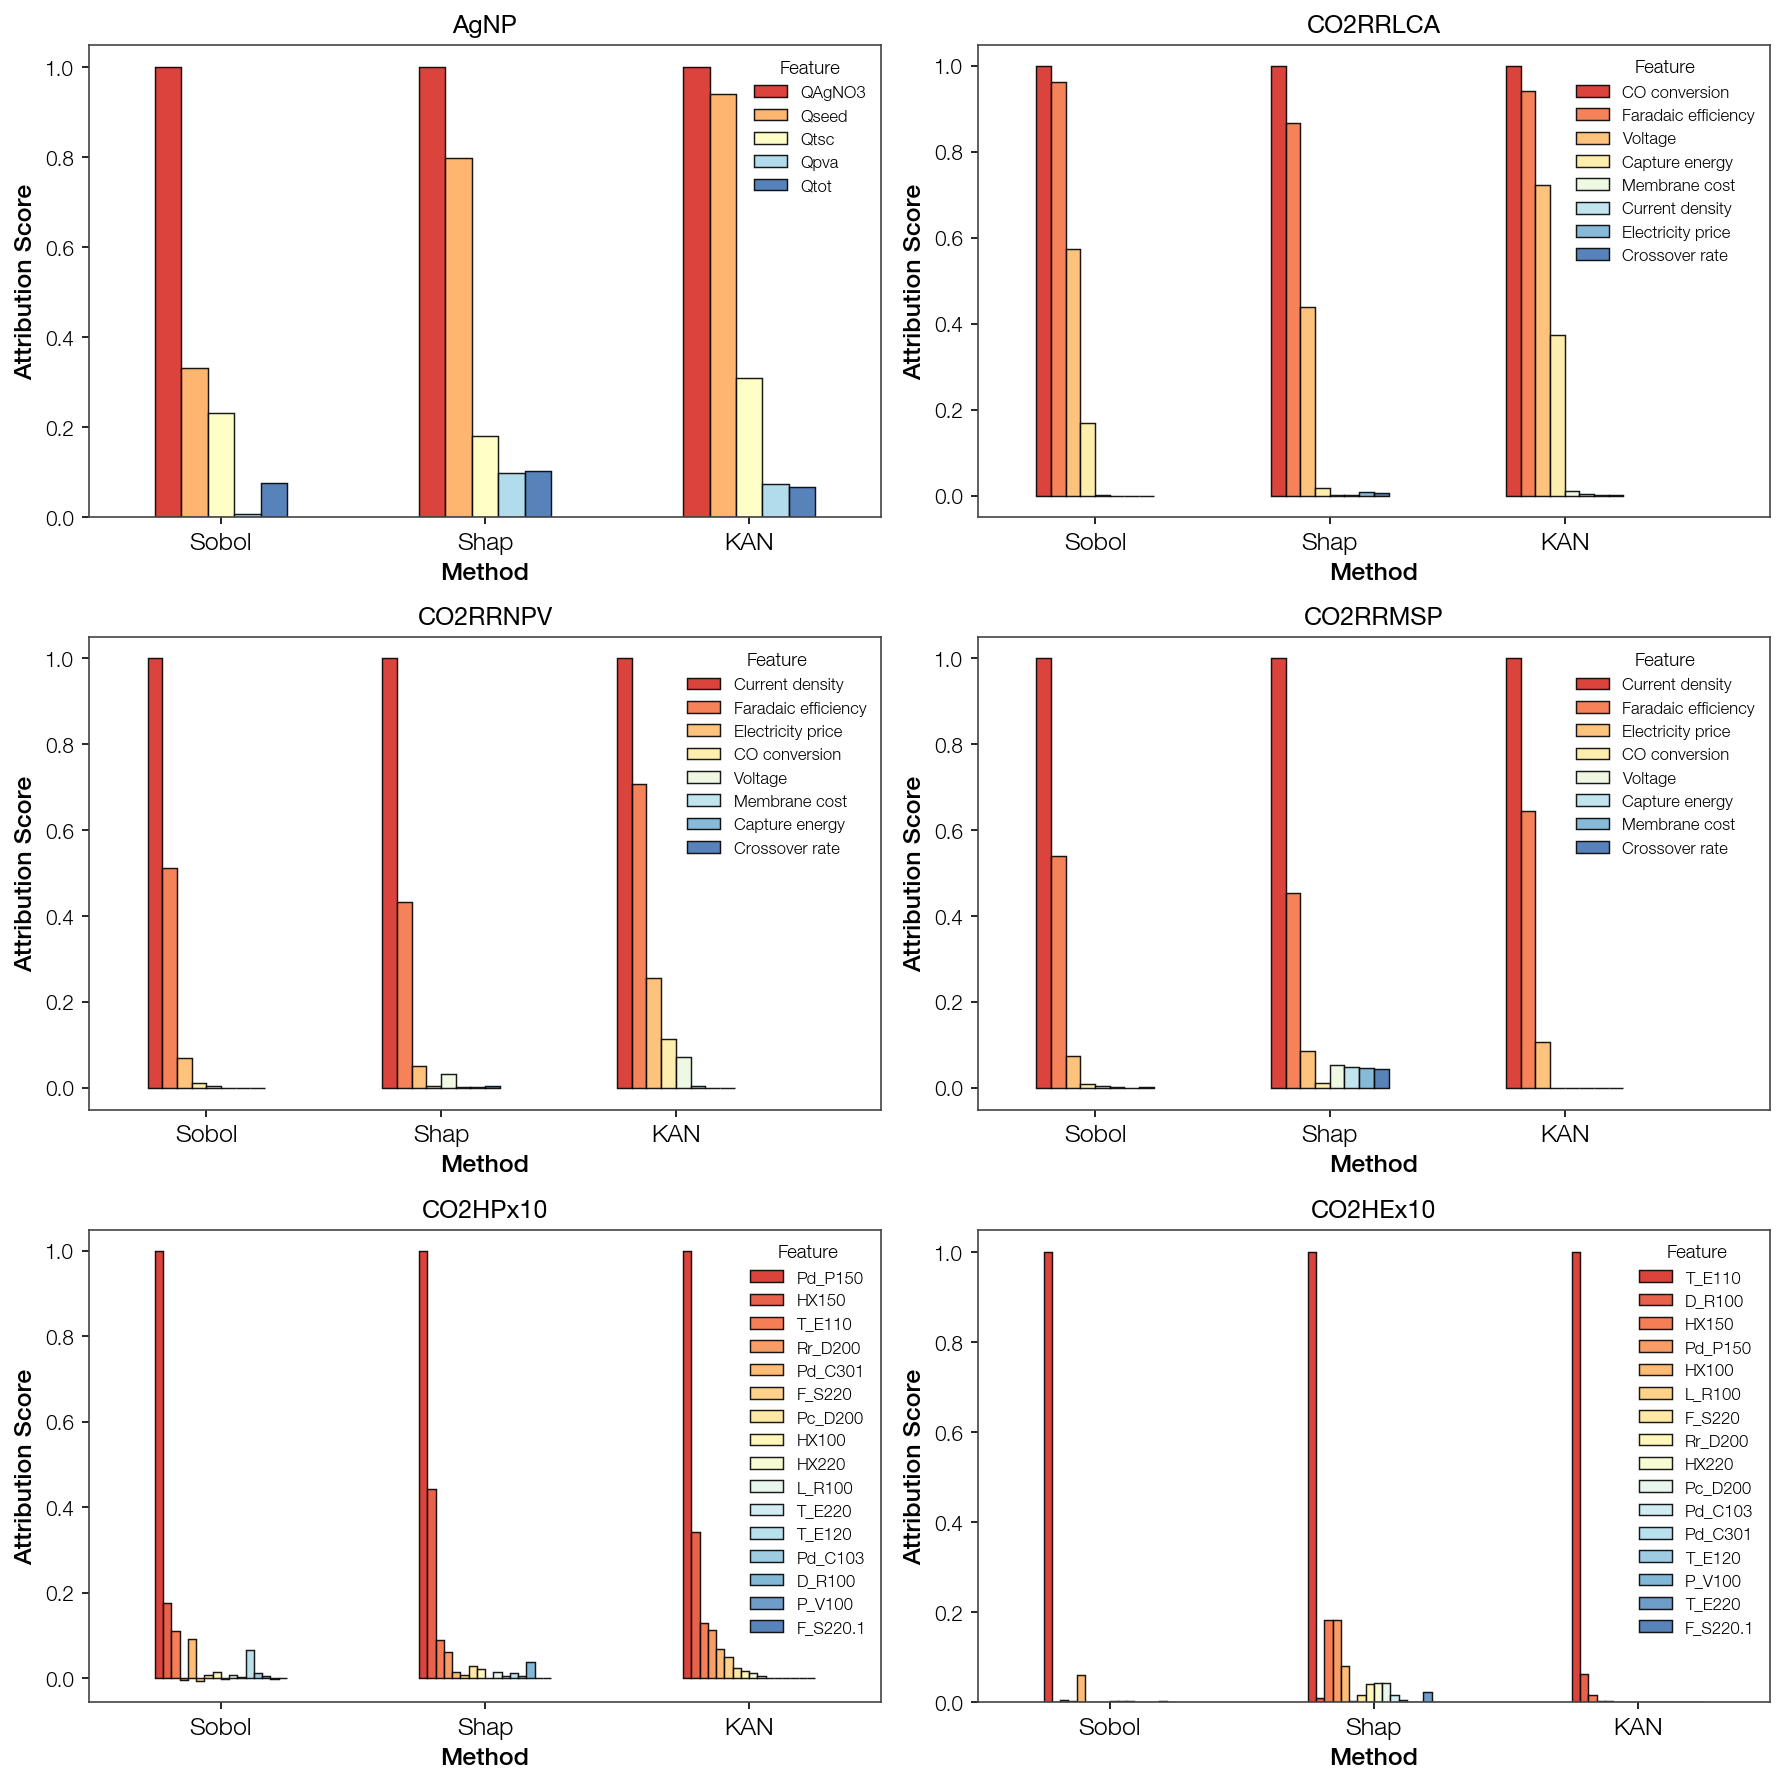

In [7]:
import pandas as pd
import os
import numpy as np

data_list = [
        'AgNP',
        'CO2RRLCA',
        'CO2RRNPV',
        'CO2RRMSP',
        'CO2HPx10',
        'CO2HEx10',
]

def get_analysis_res(name_data):
    root_dir = r"D:\pykan\github\workflows\Hyein"
    file_sobol = os.path.join(root_dir, "material_nn_models", name_data, f"{name_data}_sobol_indices.csv")
    file_shap = os.path.join(root_dir, "material_nn_models", name_data, f"{name_data}_shap_importance.csv")
    file_kan = os.path.join(root_dir, "material_kan_models", name_data, f"{name_data}_global_attribution_scores.csv")

    files = [file_sobol, file_shap, file_kan]
    columns = ['First_Order (S1)', 'Mean_Abs_SHAP', 'Global_Attribution_Score']
    methods = ['Sobol', 'Shap', 'KAN']

    dfs = [pd.read_csv(f) for f in files]
    dfs = [d.set_index('Feature') for d in dfs]
    s_ALL = [d[c] for d, c in zip(dfs, columns)]
    df_methods = pd.concat(s_ALL, axis=1)
    df_methods.columns = methods
    df_methods.sort_values('KAN', inplace=True, ascending=False)
    df_methods[methods] = df_methods[methods] / df_methods[methods].max()

    df_methods.index = df_methods.index.str.replace(r'\s*\(.*?\)', '', regex=True)

    # Transpose the DataFrame so Methods become the rows (x-axis)
    # and Features become the columns (individual bars per group)
    df_transposed = df_methods.T
    return df_transposed

def plot_analysis_res(name_data, ax, df):
    num_feat = len(df.columns)
    cmap = plt.get_cmap('RdYlBu')
    custom_colors = [cmap(x) for x in np.linspace(0.1, 0.9, num_feat)]
    df.plot(kind='bar', rot=0, color=custom_colors, alpha=0.9, ax=ax)

    # 4. Customize axes and labels
    ax.set_xlabel('Method')
    ax.set_ylabel('Attribution Score')
    if "CO2RR" in name_data:
        ax.legend(title='Feature', loc='upper right')
        x_min, x_max = ax.get_xlim()
        ax.set_xlim([x_min, x_max*1.15])
    else:
        ax.legend(title='Feature')
    ax.set_title(name_data)

df_data = [get_analysis_res(data) for data in data_list]
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes_flat = axes.flatten()
for data, df_target, ax_target in zip(data_list, df_data, axes_flat):
    plot_analysis_res(data, ax_target, df_target)

# Adjust layout and display
plt.savefig(os.path.join(dir_paper_figure, f"VS_conventionals_All.png"))
plt.savefig(os.path.join(dir_paper_figure, f"VS_conventionals_All.svg"), format='svg')
plt.show()

## 씨드 별로 업로드 -> importance 값 average -> 평균값 기준으로 순위 정하기

In [4]:
import pandas as pd
import os
import numpy as np

name_data = 'CO2RRLCA'
seed_list = [i for i in range(10)]
methods = ['Sobol', 'Shap', 'KAN']

def get_data(data, seed):
    root_dir = r"D:\pykan\github\workflows\Hyein"

    file_sobol = os.path.join(root_dir, "material_nn_models", data + f"_seed_{seed}", f"{data}_sobol_indices.csv")
    file_shap = os.path.join(root_dir, "material_nn_models", data + f"_seed_{seed}", f"{data}_shap_importance.csv")
    file_kan = os.path.join(root_dir, "material_kan_models", data, f"{data}_global_attribution_scores.csv")

    files = [file_sobol, file_shap, file_kan]
    columns = ['First_Order (S1)', 'Mean_Abs_SHAP', 'Global_Attribution_Score']

    dfs = [pd.read_csv(f) for f in files]
    dfs = [d.set_index('Feature') for d in dfs]
    s_ALL = [d[c] for d, c in zip(dfs, columns)]
    df_methods = pd.concat(s_ALL, axis=1)
    df_methods.columns = methods
    df_methods.sort_values('KAN', inplace=True, ascending=False)
    # df_methods[methods] = df_methods[methods] / df_methods[methods].max()

    df_methods.index = df_methods.index.str.replace(r'\s*\(.*?\)', '', regex=True)
    return df_methods

df_seed = []
for seed in seed_list:
    df_seed.append(get_data(name_data, seed))

avg_importance = []
for m in methods:
    cols_method = []
    for seed, df in zip(seed_list, df_seed):
        col = pd.DataFrame(df[m])
        col.columns = [seed]
        cols_method.append(col)
    all_importance = pd.concat(cols_method, axis=1)
    print("Sum of attribution with " + m)
    print(all_importance.sum().values)
    col_avg = all_importance.sum(axis=1) / all_importance.shape[1]
    col_avg = col_avg / col_avg.max()
    avg_importance.append(col_avg)
df_avg_importance = pd.concat(avg_importance, axis=1)
df_avg_importance.columns = methods
print(df_avg_importance)

Sum of attribution with Sobol
[0.97892317 0.97567493 0.97868933 0.9752952  0.97811503 0.9741863
 0.97874685 0.9736641  0.97568228 0.976942  ]
Sum of attribution with Shap
[0.19844484 0.19946187 0.19908245 0.1989309  0.19804349 0.1984561
 0.19893086 0.19976828 0.19836818 0.19889854]
Sum of attribution with KAN
[1.89631809 1.89631809 1.89631809 1.89631809 1.89631809 1.89631809
 1.89631809 1.89631809 1.89631809 1.89631809]
                        Sobol      Shap       KAN
Feature                                          
CO conversion        1.000000  0.944986  1.000000
Faradaic efficiency  0.920965  1.000000  0.940916
Voltage              0.571769  0.762879  0.723682
Capture energy       0.160726  0.414104  0.373417
Membrane cost        0.000016  0.005789  0.011476
Current density      0.000128  0.007652  0.003466
Electricity price    0.000085  0.004563  0.001999
Crossover rate       0.000032  0.004528  0.001709


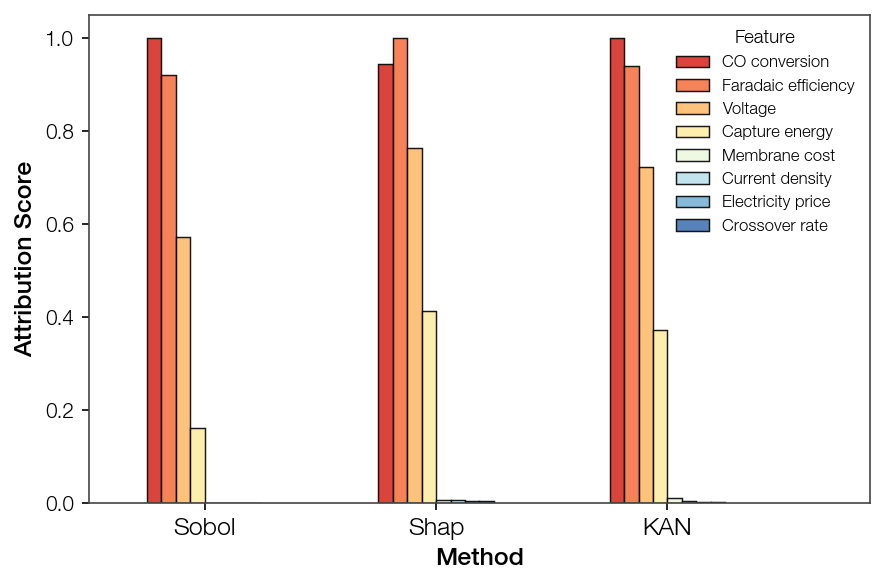

In [38]:
# Transpose the DataFrame so Methods become the rows (x-axis)
# and Features become the columns (individual bars per group)
df_transposed = df_avg_importance.T

# 3. Create the plot using pandas built-in wrapper
# This automatically handles dynamic counts of features
num_feat = len(df_transposed.columns)
cmap = plt.get_cmap('RdYlBu')
custom_colors = [cmap(x) for x in np.linspace(0.1, 0.9, num_feat)]
ax = df_transposed.plot(kind='bar', rot=0, color=custom_colors, alpha=0.9)

# 4. Customize axes and labels
ax.set_xlabel('Method')
ax.set_ylabel('Attribution Score')
if "CO2RR" in name_data:
    # ax.legend(title='Feature', loc='upper center', ncols=4)
    # y_min, y_max = ax.get_ylim()
    # ax.set_ylim([y_min, y_max*1.2])

    ax.legend(title='Feature', loc='upper right')
    x_min, x_max = ax.get_xlim()
    ax.set_xlim([x_min, x_max*1.15])

else:
    ax.legend(title='Feature')

# Adjust layout and display
plt.savefig(os.path.join(root_dir, "material_kan_models", name_data, f"{name_data}_VS_conventional_seed10.png"))
plt.savefig(os.path.join(root_dir, "material_kan_models", name_data, f"{name_data}_VS_conventional_seed10.svg"), format='svg')
plt.savefig(os.path.join(dir_paper_figure, f"VS_conventionals_{name_data}_seed10.png"))
plt.savefig(os.path.join(dir_paper_figure, f"VS_conventionals_{name_data}_seed10.svg"), format='svg')
plt.show()